# 01 Baseline Model — total_time_min

Notebook นี้สร้าง **Baseline Models** สำหรับทำนาย `total_time_min`

Models ที่ใช้:
- **DummyRegressor** (mean baseline)
- **Linear Regression**
- **Ridge Regression**
- **Lasso Regression**

Metrics:
- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error
- **R²** — Coefficient of Determination

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
from pathlib import Path

RANDOM_STATE = 42
MODEL_DIR = Path('../../models')
FIGURE_DIR = Path('../../reports/figures')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded ✓')

Libraries loaded ✓


## Load Train / Test Data

โหลดข้อมูลจาก `data/processed/` ที่แบ่งไว้แล้วใน `06_TrainTestSplit.ipynb`

In [98]:
TARGET = 'total_time_min'

train_df = pd.read_csv('../../data/processed/train.csv', encoding='utf-8-sig')
test_df  = pd.read_csv('../../data/processed/test.csv',  encoding='utf-8-sig')

# ใช้ทุก column ใน CSV ยกเว้น target (feature selection ทำไว้แล้วใน 06_TrainTestSplit)
feature_cols = [c for c in train_df.columns if c != TARGET]

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET]
X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET]

print(f'Train : X={X_train.shape}  y={y_train.shape}')
print(f'Test  : X={X_test.shape}   y={y_test.shape}')
print(f'\nFeatures ({len(X_train.columns)}):')
for i, c in enumerate(X_train.columns, 1):
    r = X_train[c].corr(y_train) if pd.api.types.is_numeric_dtype(X_train[c]) else float('nan')
    print(f'  {i:2d}. {c:<40}  r={r:+.3f}')

Train : X=(17668, 14)  y=(17668,)
Test  : X=(4417, 14)   y=(4417,)

Features (14):
   1. PickListType                              r=+0.277
   2. CarType                                   r=+0.518
   3. PrepareForward                            r=+0.294
   4. total_tile_amount                         r=+0.581
   5. total_fitting_amount                      r=+0.330
   6. total_sap_amount                          r=+0.616
   7. product_group_count                       r=+0.223
   8. queue_waiting                             r=+0.036
   9. queue_loading                             r=+0.048
  10. sap_per_group                             r=+0.386
  11. queue_x_sap                               r=+0.309
  12. rolling_avg_time_last5                    r=+0.109
  13. car_type_x_sap                            r=+0.604
  14. rolling_avg_cartype_last10                r=+0.460


## Check Data Types

ตรวจสอบ dtype ของ features ทั้งหมด — ต้องเป็น numeric ทั้งหมดสำหรับ linear models

In [99]:
# ตรวจสอบ dtype
dtype_info = X_train.dtypes.value_counts()
print('dtype distribution:')
print(dtype_info)

non_numeric = X_train.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric:
    print(f'\nNon-numeric columns found: {non_numeric}')
else:
    print('\nAll features are numeric')

missing = X_train.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    print(f'\nColumns with missing values:')
    print(missing_cols)
else:
    print('No missing values in train set')

dtype distribution:
float64    11
int64       3
Name: count, dtype: int64

All features are numeric

Columns with missing values:
CarType                       2
car_type_x_sap                2
rolling_avg_cartype_last10    2
dtype: int64


In [100]:
# Drop non-numeric columns (ถ้ามี) & fill missing
non_numeric_cols = list(set(
    X_train.select_dtypes(exclude=['number']).columns.tolist() +
    X_test.select_dtypes(exclude=['number']).columns.tolist()
))
if non_numeric_cols:
    print(f'Dropping non-numeric columns: {non_numeric_cols}')
    X_train = X_train.drop(columns=non_numeric_cols)
    X_test  = X_test.drop(columns=non_numeric_cols)

X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))

FEATURE_COLS = X_train.columns.tolist()
print(f'Final features : {len(FEATURE_COLS)} columns')

Final features : 14 columns


## Helper: Evaluate Model

In [101]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model และ return metrics dict"""
    model.fit(X_tr, y_tr)
    
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)
    
    result = {
        'model'     : name,
        'train_mae' : mean_absolute_error(y_tr, y_pred_train),
        'test_mae'  : mean_absolute_error(y_te, y_pred_test),
        'train_rmse': np.sqrt(mean_squared_error(y_tr, y_pred_train)),
        'test_rmse' : np.sqrt(mean_squared_error(y_te, y_pred_test)),
        'train_r2'  : r2_score(y_tr, y_pred_train),
        'test_r2'   : r2_score(y_te, y_pred_test),
    }
    return result, model

results = []
trained_models = {}
print('Helper function ready ✓')

Helper function ready ✓


## 1. DummyRegressor (Mean Baseline)

Predict ค่า mean ของ training set เสมอ — เป็น lower bound ที่ทุก model ต้องทำได้ดีกว่า

In [102]:
dummy = DummyRegressor(strategy='mean')
res, trained_dummy = evaluate_model('DummyRegressor (Mean)', dummy, X_train, y_train, X_test, y_test)
results.append(res)
trained_models['DummyRegressor'] = trained_dummy

print(f"{'Metric':<15} {'Train':>10} {'Test':>10}")
print('-' * 38)
print(f"{'MAE':<15} {res['train_mae']:>10.2f} {res['test_mae']:>10.2f}")
print(f"{'RMSE':<15} {res['train_rmse']:>10.2f} {res['test_rmse']:>10.2f}")
print(f"{'R²':<15} {res['train_r2']:>10.2f} {res['test_r2']:>10.2f}")

Metric               Train       Test
--------------------------------------
MAE                  17.26      17.46
RMSE                 21.53      21.72
R²                    0.00      -0.00


## 2. Linear Regression

In [103]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression()),
])

res, trained_lr = evaluate_model('LinearRegression', lr_pipeline, X_train, y_train, X_test, y_test)
results.append(res)
trained_models['LinearRegression'] = trained_lr

print(f"{'Metric':<15} {'Train':>10} {'Test':>10}")
print('-' * 38)
print(f"{'MAE':<15} {res['train_mae']:>10.2f} {res['test_mae']:>10.2f}")
print(f"{'RMSE':<15} {res['train_rmse']:>10.2f} {res['test_rmse']:>10.2f}")
print(f"{'R²':<15} {res['train_r2']:>10.2f} {res['test_r2']:>10.2f}")

Metric               Train       Test
--------------------------------------
MAE                  11.91      11.92
RMSE                 15.11      15.15
R²                    0.51       0.51


## 3. Ridge Regression (L2)

In [104]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=10.0, random_state=RANDOM_STATE)),
])

res, trained_ridge = evaluate_model('Ridge (alpha=10)', ridge_pipeline, X_train, y_train, X_test, y_test)
results.append(res)
trained_models['Ridge'] = trained_ridge

print(f"{'Metric':<15} {'Train':>10} {'Test':>10}")
print('-' * 38)
print(f"{'MAE':<15} {res['train_mae']:>10.2f} {res['test_mae']:>10.2f}")
print(f"{'RMSE':<15} {res['train_rmse']:>10.2f} {res['test_rmse']:>10.2f}")
print(f"{'R²':<15} {res['train_r2']:>10.2f} {res['test_r2']:>10.2f}")

Metric               Train       Test
--------------------------------------
MAE                  11.91      11.92
RMSE                 15.11      15.14
R²                    0.51       0.51


## 4. Lasso Regression (L1)

In [105]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=5000)),
])

res, trained_lasso = evaluate_model('Lasso (alpha=1)', lasso_pipeline, X_train, y_train, X_test, y_test)
results.append(res)
trained_models['Lasso'] = trained_lasso

print(f"{'Metric':<15} {'Train':>10} {'Test':>10}")
print('-' * 38)
print(f"{'MAE':<15} {res['train_mae']:>10.2f} {res['test_mae']:>10.2f}")
print(f"{'RMSE':<15} {res['train_rmse']:>10.2f} {res['test_rmse']:>10.2f}")
print(f"{'R²':<15} {res['train_r2']:>10.2f} {res['test_r2']:>10.2f}")

# Lasso zero-out features
lasso_coef = trained_lasso.named_steps['model'].coef_
n_zero = (lasso_coef == 0).sum()
print(f'\nLasso zeroed-out features: {n_zero}/{len(lasso_coef)}')

Metric               Train       Test
--------------------------------------
MAE                  12.19      12.14
RMSE                 15.35      15.35
R²                    0.49       0.50

Lasso zeroed-out features: 7/14


## Summary: Compare Baseline Models

In [106]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_rmse')

display_cols = ['model', 'test_mae', 'test_rmse', 'test_r2', 'train_mae', 'train_rmse', 'train_r2']
print(results_df[display_cols].to_string(index=False, float_format='{:.2f}'.format))

                model  test_mae  test_rmse  test_r2  train_mae  train_rmse  train_r2
     Ridge (alpha=10)     11.92      15.14     0.51      11.91       15.11      0.51
     LinearRegression     11.92      15.15     0.51      11.91       15.11      0.51
      Lasso (alpha=1)     12.14      15.35     0.50      12.19       15.35      0.49
DummyRegressor (Mean)     17.46      21.72    -0.00      17.26       21.53      0.00


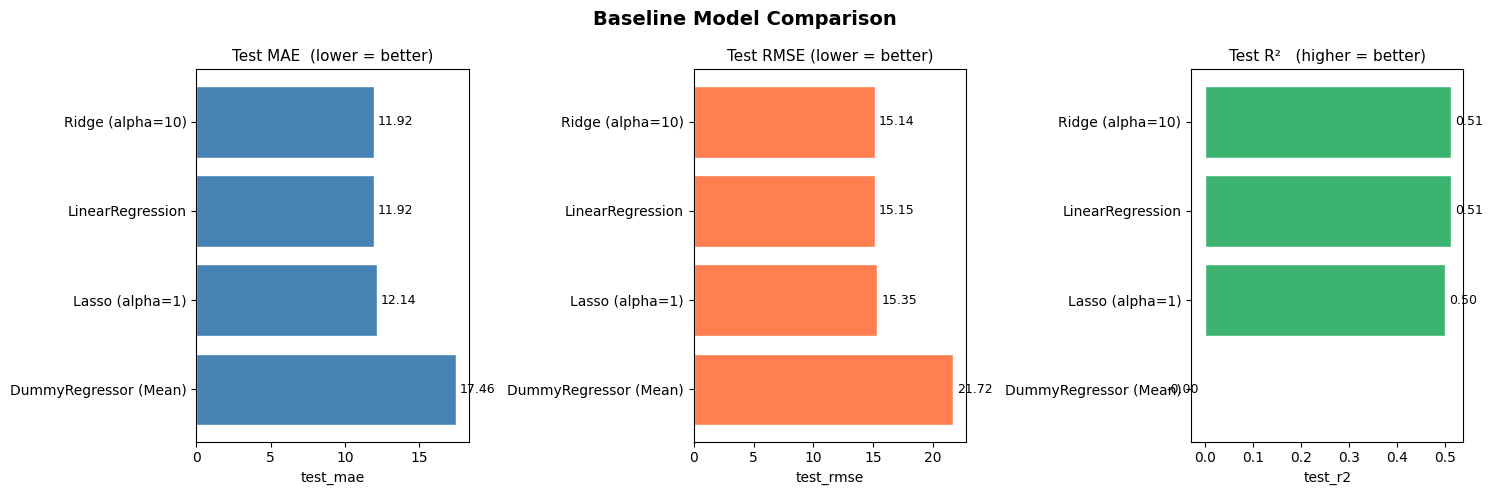

Figure saved ✓


In [107]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Baseline Model Comparison', fontsize=14, fontweight='bold')

metrics = [
    ('test_mae',  'Test MAE  (lower = better)',  'steelblue'),
    ('test_rmse', 'Test RMSE (lower = better)', 'coral'),
    ('test_r2',   'Test R²   (higher = better)', 'mediumseagreen'),
]

for ax, (col, title, color) in zip(axes, metrics):
    bars = ax.barh(results_df['model'], results_df[col], color=color, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_xlabel(col)
    ax.invert_yaxis()

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'baseline_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

## Save Best Baseline Model & Results

In [108]:
# Save best baseline (lowest test RMSE ยกเว้น Dummy)
non_dummy = results_df[results_df['model'] != 'DummyRegressor (Mean)']
best_name = non_dummy.iloc[0]['model']
print(f'Best baseline : {best_name}')

model_key_map = {
    'LinearRegression' : 'LinearRegression',
    'Ridge (alpha=10)' : 'Ridge',
    'Lasso (alpha=1)'  : 'Lasso',
}
best_key = model_key_map.get(best_name, best_name)
best_model = trained_models[best_key]

save_path = MODEL_DIR / 'baseline_best_totaltime.joblib'
joblib.dump(best_model, save_path)
print(f'Model saved → {save_path}')

results_path = MODEL_DIR / 'baseline_results_totaltime.csv'
results_df.to_csv(results_path, index=False)
print(f'Results saved → {results_path}')

Best baseline : Ridge (alpha=10)
Model saved → ..\..\models\baseline_best_totaltime.joblib
Results saved → ..\..\models\baseline_results_totaltime.csv


## Summary

| Step | Detail |
|------|--------|
| Target | `total_time_min` |
| Data | `data/processed/train.csv` + `test.csv` |
| Features | 32 features (selected in `06_TrainTestSplit.ipynb`) |
| Models | DummyRegressor, LinearRegression, Ridge, Lasso |
| Metrics | MAE, RMSE, R² (Train & Test) |
| Output | `models/baseline_best.joblib`, `models/baseline_results.csv` |

Next: `02_AdvancedModels.ipynb` — Random Forest, XGBoost, LightGBM